# Name : Bansi Ajagia
# **Subject** : Machine Learning
# **Project** : Cardiovascular Disease Prediction System

---

# Task 2 — Data Cleaning & Preprocessing

## 1️⃣ Load Raw Data

In [5]:
# Name : Bansi Ajagia
# Subject : Machine Learning
# Project : Cardiovascular Disease Prediction System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cardio.csv', sep=';')
print(f'Raw shape: {df.shape}')

Raw shape: (70000, 13)


## 2️⃣ Handle Missing Values

In [7]:
print('Missing values:')
print(df.isnull().sum())
# No missing values in this dataset — confirmed!

Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


## 3️⃣ Remove Duplicates

In [9]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Removed {before - after} duplicate rows.')

Removed 0 duplicate rows.


## 4️⃣ Handle Outliers (Blood Pressure, Height, Weight)

In [11]:
# Age conversion
df['age_years'] = (df['age'] / 365).round(0).astype(int)

# Remove physiologically impossible values
before = len(df)
df = df[df['ap_hi'].between(60, 250)]
df = df[df['ap_lo'].between(40, 200)]
df = df[df['height'].between(100, 250)]
df = df[df['weight'].between(30, 250)]
after = len(df)
print(f'Removed {before - after} outlier rows.')
print(f'Clean dataset shape: {df.shape}')

Removed 1257 outlier rows.
Clean dataset shape: (68743, 14)


## 5️⃣ Feature Scaling with StandardScaler

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

FEATURE_COLS = ['age_years','gender','height','weight',
                'ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']

X = df[FEATURE_COLS].values
y = df['cardio'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')

Train size: (54994, 11)
Test size:  (13749, 11)


## 6️⃣ Basic EDA Plots

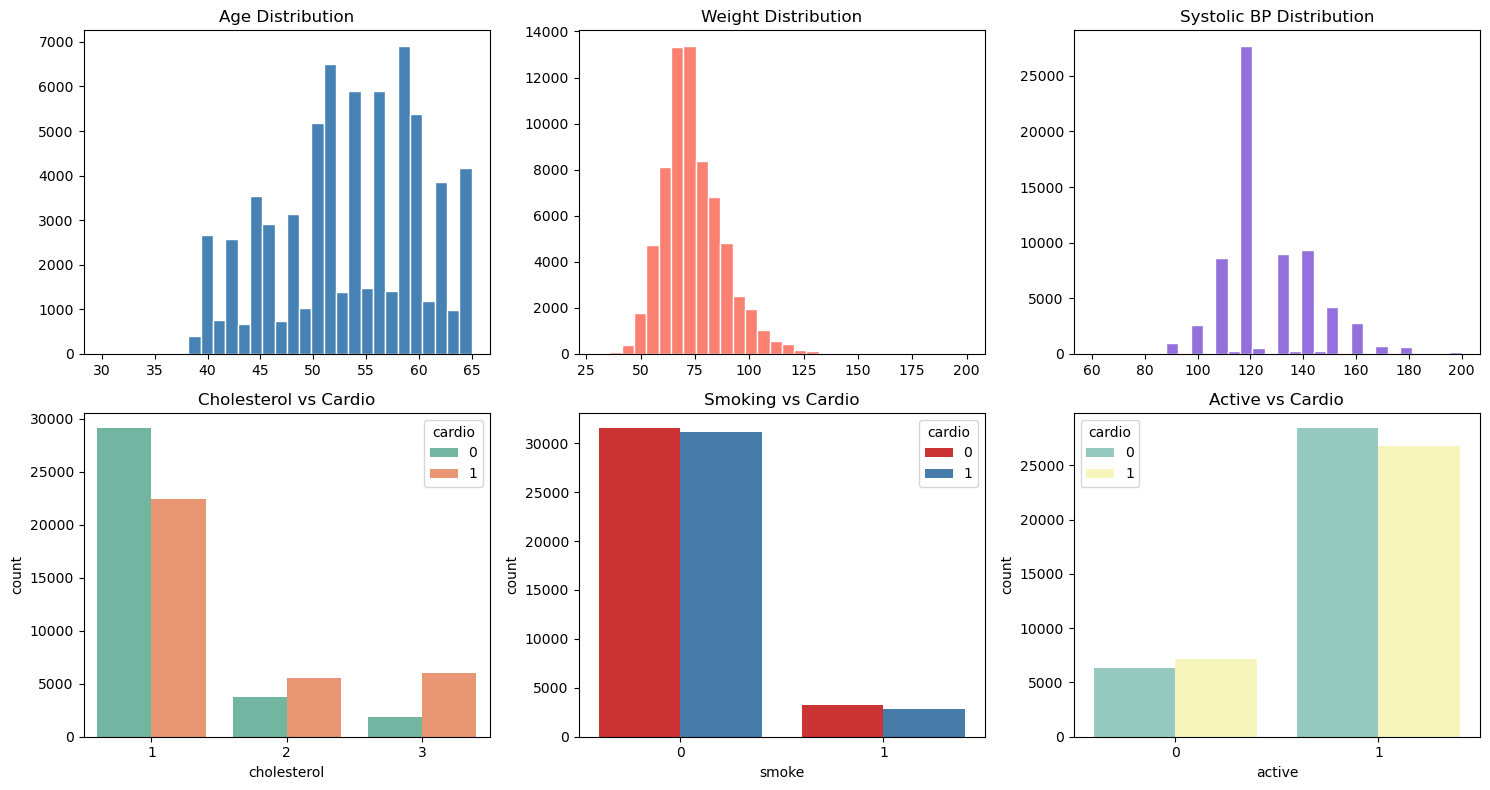

EDA plots saved!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(df['age_years'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')

axes[0,1].hist(df['weight'], bins=30, color='salmon', edgecolor='white')
axes[0,1].set_title('Weight Distribution')

axes[0,2].hist(df['ap_hi'].clip(60,200), bins=30, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Systolic BP Distribution')

sns.countplot(data=df, x='cholesterol', hue='cardio', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Cholesterol vs Cardio')

sns.countplot(data=df, x='smoke', hue='cardio', palette='Set1', ax=axes[1,1])
axes[1,1].set_title('Smoking vs Cardio')

sns.countplot(data=df, x='active', hue='cardio', palette='Set3', ax=axes[1,2])
axes[1,2].set_title('Active vs Cardio')

plt.tight_layout()
plt.savefig('../outputs/eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA plots saved!')